# Практическое задание: Преобразование категорий и нормализация признаков

Вы работаете аналитиком в банке. Необходимо подготовить данные о заявителях по кредитам для построения модели машинного обучения, которая будет прогнозировать решение по кредитной заявке.

В качестве исходных данных используется датасет loan_approval_data_2025.csv.

Целевая переменная:

loan_status - результат рассмотрения заявки (например, одобрена или отклонена).

Перед обучением модели необходимо выполнить анализ структуры данных, преобразовать категориальные признаки в числовой формат и подготовить числовые признаки с помощью различных методов масштабирования.

Загрузка датасета:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("Loan_approval_data_2025.csv")

df = pd.DataFrame(data)

# Задачи для выполнения
# Задача 1: Исследовательский анализ данных
Условие: Проведите исследовательский анализ данных.

Определите:
1. Количество строк и столбцов.
2. Какие признаки являются числовыми, а какие - категориальными.
3. Наличие пропущенных значений.

4. Количество уникальных значений для каждого категориального признака.

5. (*) Построить гистограммы распределения для всех числовых признаков.

6. Сделать краткий вывод о структуре набора данных.

In [2]:
df.head(10)

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1
5,CUST100005,32,Employed,13.4,32015,570,7.3,253,1120,0,0,2,Credit Card,Personal,37000,22.92,0.035,1.156,0.385,0
6,CUST100006,53,Employed,22.9,44989,674,11.1,19667,19298,0,0,0,Personal Loan,Home Improvement,45600,11.02,0.429,1.014,0.338,1
7,CUST100007,44,Self-Employed,4.2,80603,625,18.5,830,38382,0,0,0,Credit Card,Personal,51700,19.42,0.476,0.641,0.214,1
8,CUST100008,29,Employed,5.9,28416,569,2.6,1334,22668,1,2,0,Credit Card,Education,33800,22.72,0.798,1.189,0.396,0
9,CUST100009,41,Employed,7.0,70717,638,21.5,1578,21394,0,1,0,Credit Card,Personal,70000,19.35,0.303,0.990,0.330,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [4]:
df.describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.957060,7.454868,50062.892040,643.614820,8.168274,3595.619400,14290.442220,0.053480,0.55464,0.147640,33041.874000,15.498591,0.285724,0.701999,0.233995,0.550460
std,11.118603,7.612097,32630.501014,64.731518,7.207552,13232.399398,13243.757493,0.224991,0.84505,0.412996,26116.185102,4.067942,0.159787,0.465788,0.155268,0.497452
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,0.00000,0.000000,500.000000,6.000000,0.002000,0.008000,0.003000,0.000000
25%,26.000000,1.300000,27280.500000,600.000000,2.000000,130.000000,5581.000000,0.000000,0.00000,0.000000,12300.000000,12.180000,0.161000,0.333000,0.111000,0.000000
50%,35.000000,4.900000,41607.500000,643.000000,6.100000,568.000000,10385.000000,0.000000,0.00000,0.000000,26100.000000,15.440000,0.265000,0.622000,0.207000,1.000000
75%,43.000000,11.400000,62723.250000,687.000000,12.600000,2271.000000,18449.250000,0.000000,1.00000,0.000000,48500.000000,18.870000,0.389000,1.010250,0.337000,1.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,9.00000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000,1.000000


In [5]:
# пропусков
df.isna().sum().sum()

np.int64(0)

In [6]:
# уникальных значений
df[['customer_id', 'occupation_status', 'defaults_on_file', 'product_type', 'loan_intent', 'loan_status']].nunique()

customer_id          50000
occupation_status        3
defaults_on_file         2
product_type             3
loan_intent              6
loan_status              2
dtype: int64

1. Количество строк: 50000
2. Количество столбцов: 20
3. Числовые признаки: age, years_employed, annual_income, credit_score, credit_history_years, savings_assets, current_debt, delinquencies_last_2yrs, derogatory_marks, loan_amount, interest_rate, debt_to_income_ratio, loan_to_income_ratio, payment_to_income_ratio.
4. Категориальные признаки: customer_id, occupation_status, defaults_on_file, product_type, loan_intent, loan_status.
5. Пропусков: 0
6. Уникальных значений:
- customer_id          50000
- occupation_status        3
- defaults_on_file         2
- product_type             3
- loan_intent              6
- loan_status              2

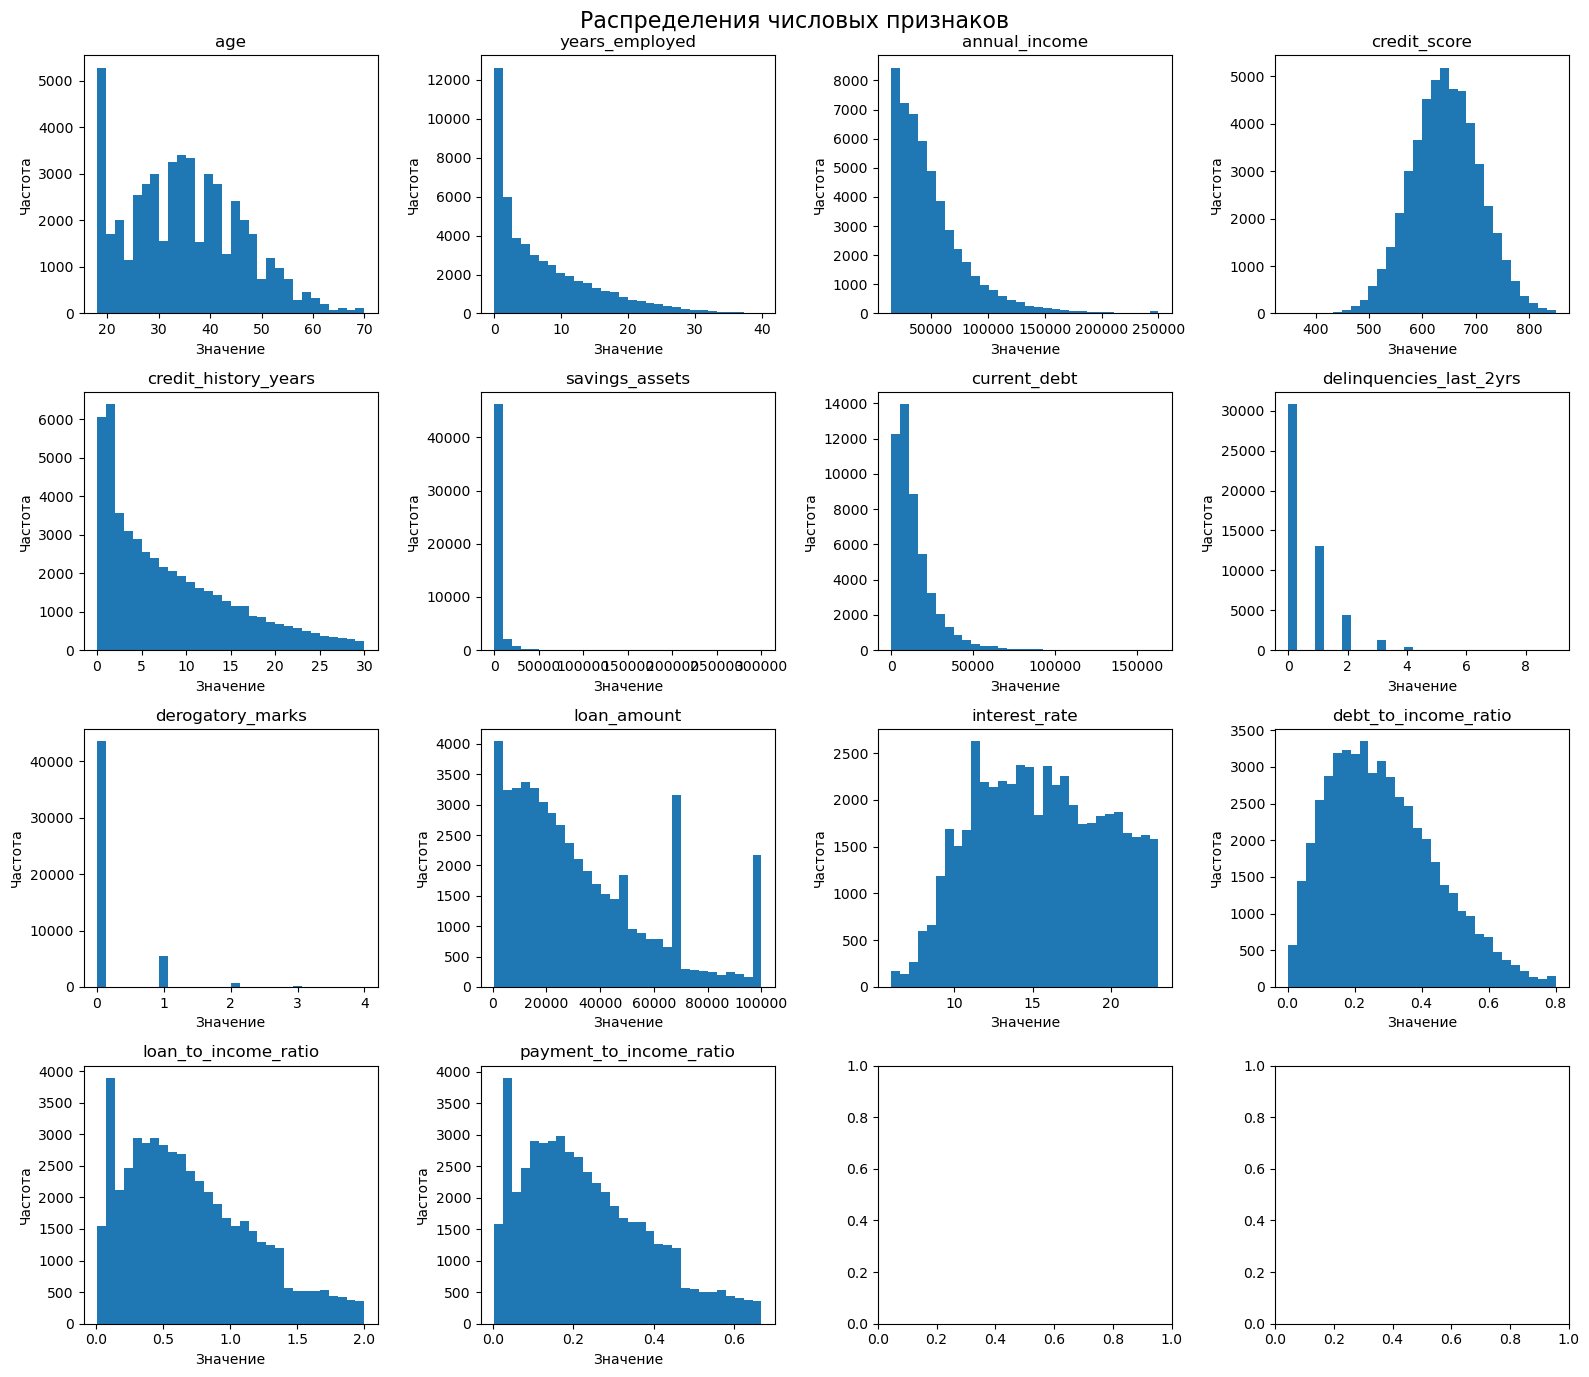

In [ ]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop(['defaults_on_file', 'loan_status'])

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(16, 14)
)

axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    axes[i].hist(df[column], bins=30)
    axes[i].set_title(column)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

plt.suptitle('Распределения числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

Вывод о структуре датасета:

Набор данных содержит 50000 строк и 20 столбцов, характеризующих клиентов и их кредитные заявки. Большинство признаков являются числовыми и описывают возраст, доход, кредитную историю, задолженность, размер займа и прочие финансовые данные. Шесть признаков имеют категориальный тип, при этом customer_id является идентификатором клиента. Пропущенные значения отсутствуют, поэтому предварительная обработка пропусков не требуется. Целевая переменная loan_status является бинарной. Набор данных структурирован и пригоден для дальнейшего анализа.

# Задача 2: Преобразование категориальных признаков
Перед обучением модели необходимо преобразовать категориальные признаки в числовую форму.

Требования
1. Выберите один категориальный признак, имеющий небольшое количество уникальных значений, и выполните для него Label Encoding.
2. Выберите один номинальный категориальный признак (например, семейное положение, образование, тип занятости или аналогичный признак из датасета) и выполните One-Hot Encoding.
3. Выберите категориальный признак с несколькими повторяющимися категориями и выполните Frequency Encoding.
4. Создайте новый DataFrame, содержащий исходные числовые признаки и преобразованные категориальные признаки.
5. Сделайте вывод о том, в каких случаях каждый метод кодирования является наиболее подходящим.

Примечание.
 Конкретные признаки выбираются студентом исходя из структуры датасета.

In [8]:
# 1. Label Encoding

from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

label_encoder = LabelEncoder()
df_encoded['occupation_status'] = label_encoder.fit_transform(
    df_encoded['occupation_status']
)

print(df_encoded[['occupation_status']].head())
print(label_encoder.classes_)

   occupation_status
0                  0
1                  0
2                  2
3                  2
4                  0
['Employed' 'Self-Employed' 'Student']


In [9]:
# 2. One-Hot Encoding

df_encoded = pd.get_dummies(
    df_encoded,
    columns=['product_type'],
    dtype=int
)

print(df_encoded.head())

  customer_id  age  occupation_status  years_employed  annual_income  \
0  CUST100000   40                  0            17.2          25579   
1  CUST100001   33                  0             7.3          43087   
2  CUST100002   42                  2             1.1          20840   
3  CUST100003   53                  2             0.5          29147   
4  CUST100004   32                  0            12.5          63657   

   credit_score  credit_history_years  savings_assets  current_debt  \
0           692                   5.3             895         10820   
1           627                   3.5             169         16550   
2           689                   8.4              17          7852   
3           692                   9.8            1480         11603   
4           630                   7.2             209         12424   

   defaults_on_file  ...         loan_intent  loan_amount interest_rate  \
0                 0  ...            Business          600        

In [10]:
# 3. Frequency Encoding

frequency = df['loan_intent'].value_counts(normalize=True)

df_encoded['loan_intent'] = df_encoded['loan_intent'].map(frequency)

print(df_encoded[['loan_intent']].head())

   loan_intent
0      0.14938
1      0.14906
2      0.09834
3      0.14938
4      0.20268


In [11]:
# Новый датафрейм

numeric_features = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

numeric_features.remove('loan_status')

df_final = df[numeric_features].copy()

# Label Encoding
df_final['occupation_status'] = label_encoder.fit_transform(
    df['occupation_status']
)

# Frequency Encoding
df_final['loan_intent'] = df['loan_intent'].map(frequency)

# One-Hot Encoding
product_type_encoded = pd.get_dummies(
    df['product_type'],
    prefix='product_type',
    dtype=int
)

df_final = pd.concat(
    [df_final, product_type_encoded],
    axis=1
)

# Целевая переменная
df_final['loan_status'] = df['loan_status']

print(df_final.head())
print(df_final.shape)

   age  years_employed  annual_income  credit_score  credit_history_years  \
0   40            17.2          25579           692                   5.3   
1   33             7.3          43087           627                   3.5   
2   42             1.1          20840           689                   8.4   
3   53             0.5          29147           692                   9.8   
4   32            12.5          63657           630                   7.2   

   savings_assets  current_debt  defaults_on_file  delinquencies_last_2yrs  \
0             895         10820                 0                        0   
1             169         16550                 0                        1   
2              17          7852                 0                        0   
3            1480         11603                 0                        1   
4             209         12424                 0                        0   

   derogatory_marks  ...  interest_rate  debt_to_income_ratio  \
0  

Выводы:

Были применены три метода преобразования категориальных признаков. 
- Для occupation_status использовано Label Encoding, при котором каждой категории соответствует числовое значение. 
- Для product_type применено One-Hot Encoding, в результате чего каждая категория была представлена отдельным бинарным признаком. 
- Для loan_intent использовано Frequency Encoding, при котором категории заменяются частотой их появления в выборке. 

Label Encoding наиболее целесообразен для категориальных признаков с естественным порядком, One-Hot Encoding - для номинальных признаков с небольшим числом категорий, а Frequency Encoding - при наличии нескольких повторяющихся категорий..

# Задача 3: Сравнение методов кодирования
Сравните полученные способы кодирования.
Требования:

1. Определите, насколько увеличилось количество признаков после применения One-Hot Encoding.
2. Для каждого метода постройте визуализацию (*).

Например:
* для Label Encoding - столбчатую диаграмму распределения полученных кодов,
* для One-Hot Encoding - тепловую карту корреляций между созданными бинарными признаками,
*  для Frequency Encoding - график распределения полученных значений.
3. Сравните преимущества и недостатки каждого способа кодирования.
4. Сделайте вывод, какой метод предпочтительнее использовать для различных типов категориальных признаков.


1. Число признаков увеличилось на 2 признака

2. Визуализации

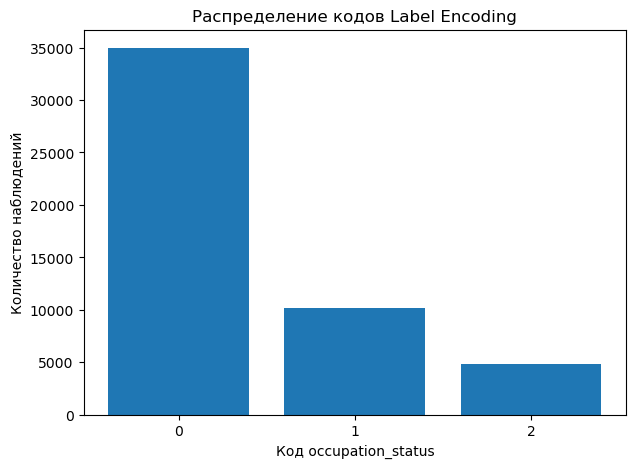

In [12]:
occupation_codes = pd.DataFrame({
    'occupation_status': df['occupation_status'],
    'code': label_encoder.transform(df['occupation_status'])
})

code_counts = occupation_codes['code'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(code_counts.index.astype(str), code_counts.values)

plt.xlabel('Код occupation_status')
plt.ylabel('Количество наблюдений')
plt.title('Распределение кодов Label Encoding')

plt.show()

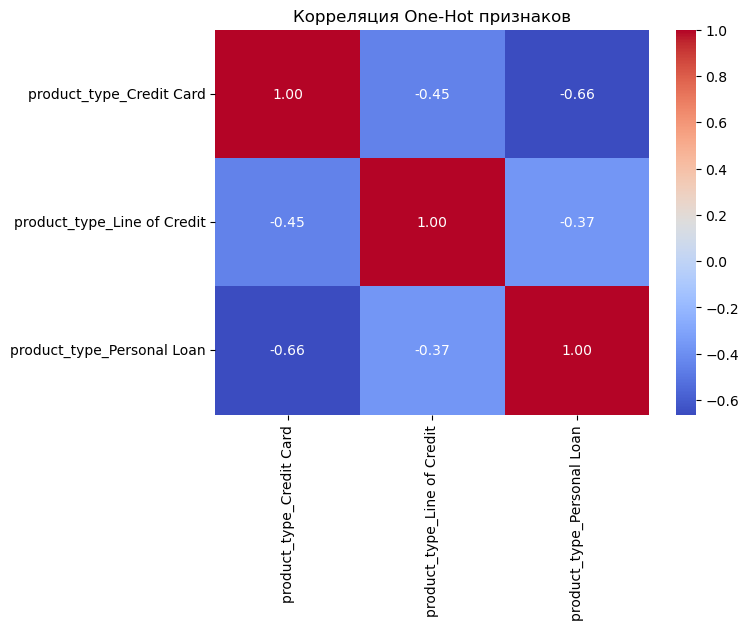

In [13]:
one_hot_columns = [
    'product_type_Credit Card',
    'product_type_Line of Credit',
    'product_type_Personal Loan'
]

df_one_hot = pd.get_dummies(
    df,
    columns=['product_type'],
    dtype=int
)

corr = df_one_hot[one_hot_columns].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Корреляция One-Hot признаков')
plt.show()

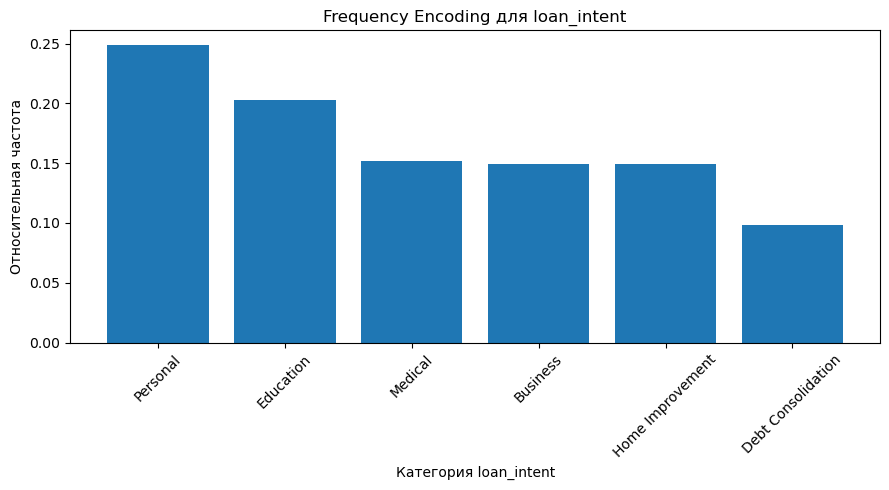

In [25]:
plt.figure(figsize=(9, 5))

plt.bar(
    frequency.index,
    frequency.values
)

plt.xlabel('Категория loan_intent')
plt.ylabel('Относительная частота')
plt.title('Frequency Encoding для loan_intent')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

3. Сравнение методов

| Метод | Преимущества   | Недостатки  |
| -- | -- | --|
| Label Encoding     | Не увеличивает число столбцов, подходит для порядковых категорий                                      | Может создать ложное представление о порядке между категориями  |
| One-Hot Encoding   | Не создаёт искусственного порядка, хорошо подходит для номинальных признаков                                    | Увеличивает количество признаков, при большом числе категорий создаёт очень широкую матрицу |
| Frequency Encoding | Один числовой признак вместо множества, не увеличивает размерность, хорошо работает при большом числе категорий | Теряется информация о самой категории, разные категории могут иметь одинаковую частоту, частота категории не обязательно связана с её содержательным значением |

4. Выводы

- One-Hot Encoding идеален для номинальных признаков с малым числом категорий. Он не создает ложного порядка, но сильно увеличивает размерность данных при множестве уникальных значений.
- Label Encoding оптимален для порядковых признаков. Он прост и сохраняет размерность, но для номинальных данных вреден, так как навязывает искусственный порядок.
-  Frequency Encoding эффективен для признаков с большим количеством категорий. Он заменяет категории частотой их появления и помогает избежать раздувания размерности.

# Задача 4: Масштабирование числовых признаков
Подготовьте числовые признаки к использованию в модели машинного обучения

Требования
1. Выберите два числовых признака, характеризующих клиента (например, возраст, доход, стаж работы или аналогичные признаки из датасета), и примените Min-Max Scaling.
2. Выберите два других числовых признака и выполните Standard Scaling.
3. Для одного числового признака выполните Robust Scaling и сравните результат со Standard Scaling.
4. (*)Постройте boxplot для выбранных признаков:
* до масштабирования,
* после масштабирования.
5. Рассчитайте основные статистики (среднее значение, стандартное отклонение, минимум и максимум) до и после преобразований.
6. Сделайте вывод о том, как различные методы масштабирования влияют на данные и в каких случаях каждый из них рекомендуется использовать.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

df_scaled = df.copy()

# 1. Min-Max Scaling для двух признаков age и debt_to_income_ratio
minmax_features = ['age', 'debt_to_income_ratio']
minmax_scaler = MinMaxScaler()

df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df[minmax_features]),
    columns=[f'{col}_minmax' for col in minmax_features],
    index=df.index
)

df_minmax.head()

,age_minmax,debt_to_income_ratio_minmax
0,0.423077,0.527569
1,0.288462,0.478697
2,0.461538,0.469925
3,0.673077,0.496241
4,0.269231,0.241855


In [16]:
# 2. Standard Scaling для двух других признаков: annual_income и credit_score
standard_features = ['annual_income', 'credit_score']
standard_scaler = StandardScaler()

df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df[standard_features]),
    columns=[f'{col}_standard' for col in standard_features],
    index=df.index
)

df_standard.head()

,annual_income_standard,credit_score_standard
0,-0.750345,0.747482
1,-0.213787,-0.256675
2,-0.895579,0.701137
3,-0.640998,0.747482
4,0.416612,-0.210330


In [17]:
# 3. Robust Scaling для current_debt и сравнение со Standard Scaling
robust_feature = ['current_debt']
robust_scaler = RobustScaler()

df_robust = pd.DataFrame(
    robust_scaler.fit_transform(df[robust_feature]),
    columns=[f'{col}_robust' for col in robust_feature],
    index=df.index
)

debt_standard_scaler = StandardScaler()
df_debt_standard = pd.DataFrame(
    debt_standard_scaler.fit_transform(df[robust_feature]),
    columns=[f'{col}_standard' for col in robust_feature],
    index=df.index
)

comparison = pd.concat([df[robust_feature], df_robust, df_debt_standard], axis=1)
comparison.head()

,current_debt,current_debt_robust,current_debt_standard
0,10820,0.033804,-0.262046
1,16550,0.479086,0.170615
2,7852,-0.196841,-0.486154
3,11603,0.094652,-0.202923
4,12424,0.158452,-0.140931


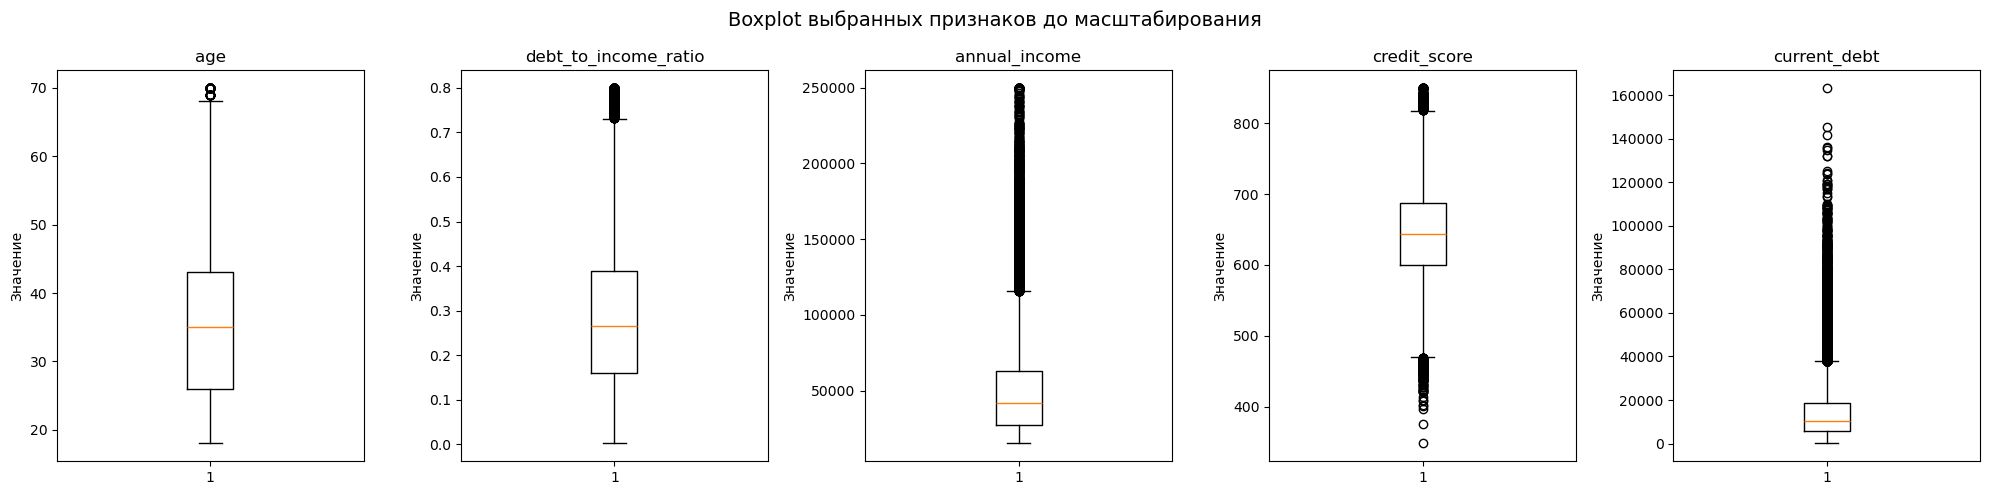

In [27]:
# 4. Boxplot выбранных признаков до масштабирования
selected_features = ['age', 'debt_to_income_ratio', 'annual_income', 'credit_score', 'current_debt']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, col in zip(axes, selected_features):
    ax.boxplot(df[col].dropna())
    ax.set_title(col)
    ax.set_ylabel('Значение')

plt.suptitle('Boxplot выбранных признаков до масштабирования', fontsize=14)
plt.tight_layout()
plt.show()

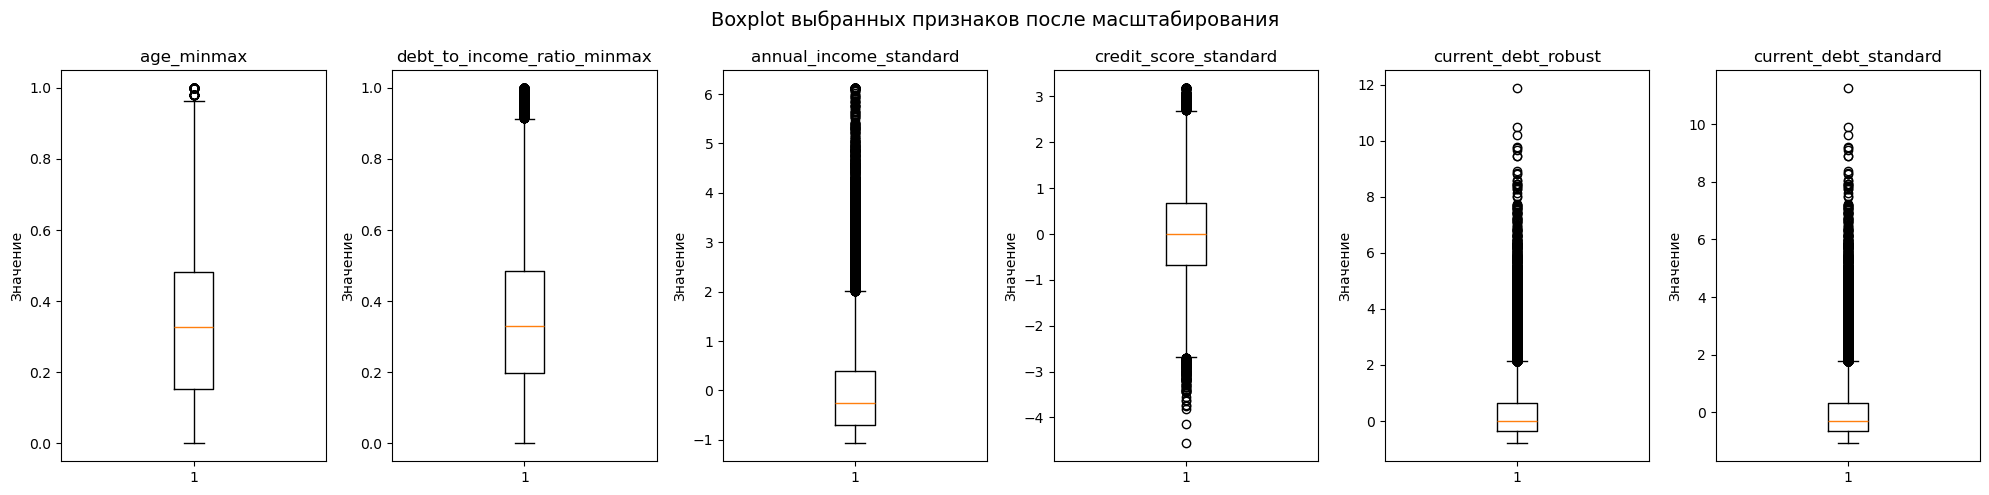

In [30]:
# Boxplot выбранных признаков после масштабирования
df_scaled_all = pd.concat([df_minmax, df_standard, df_robust, df_debt_standard], axis=1)

fig, axes = plt.subplots(1, 6, figsize=(20, 5))

for ax, col in zip(axes, df_scaled_all.columns):
    ax.boxplot(df_scaled_all[col].dropna())
    ax.set_title(col)
    ax.set_ylabel('Значение')

plt.suptitle('Boxplot выбранных признаков после масштабирования', fontsize=14)
plt.tight_layout()
plt.show()

In [31]:
# 5. Основные статистики до и после масштабирования
def get_stats(data, columns):
    return data[columns].agg(['mean', 'std', 'min', 'max']).T

print('До масштабирования')
print(get_stats(df, selected_features))

print('Min-Max Scaling')
print(get_stats(df_minmax, df_minmax.columns))

print('Standard Scaling')
print(get_stats(df_standard, df_standard.columns))

print('Robust Scaling (current_debt)')
print(get_stats(df_robust, df_robust.columns))

print('Standard Scaling (current_debt)')
print(get_stats(df_debt_standard, df_debt_standard.columns))

До масштабирования
                              mean           std        min       max
age                      34.957060     11.118603     18.000      70.0
debt_to_income_ratio      0.285724      0.159787      0.002       0.8
annual_income         50062.892040  32630.501014  15000.000  250000.0
credit_score            643.614820     64.731518    348.000     850.0
current_debt          14290.442220  13243.757493     60.000  163344.0
Min-Max Scaling
                                 mean       std  min  max
age_minmax                   0.326097  0.213819  0.0  1.0
debt_to_income_ratio_minmax  0.355544  0.200234  0.0  1.0
Standard Scaling
                                mean      std       min       max
annual_income_standard  1.932676e-17  1.00001 -1.074554  6.127369
credit_score_standard  -1.376321e-16  1.00001 -4.566829  3.188358
Robust Scaling (current_debt)
                         mean       std       min        max
current_debt_robust  0.303494  1.029181 -0.802362  11.886542
Stan

6. Вывод о влиянии методов масштабирования:

- Min-Max Scaling сжал age и years_employed в диапазон 0, 1: среднее и std уменьшились пропорционально, min = 0, max = 1.

- Standard Scaling привёл annual_income и credit_score к mean прим. 0 и std прим. 1. При этом видно, что credit_score имеет хвост до −4.57 (низкие скоры), а annual_income - до +6.13 (очень высокие доходы).

- Robust Scaling для current_debt дал max прим. 11.9 против max прим. 11.3 у Standard Scaling - разница небольшая, но Robust использует медиану и IQR, поэтому снижает влияние экстремальных значений (max = 163 344 при медиане 10 385).

## Итоговое задание

Подготовьте набор данных к дальнейшему использованию в задачах машинного обучения.

В результате работы необходимо:

* получить набор данных, содержащий только признаки, пригодные для обучения модели
* преобразовать выбранные категориальные признаки в числовой формат
* выполнить масштабирование выбранных числовых признаков
* сохранить подготовленный DataFrame для дальнейшего использования

1. исключим customer_id (идентификатор, не несёт полезной информации для модели)
2. оставим числовые признаки и преобразованные категориальные (occupation_status - Label Encoding, loan_intent - Frequency Encoding, product_type - One-Hot Encoding)
3. применим Min-Max к age и years_employed, Standard Scaling к annual_income и credit_score, Robust Scaling к current_debt
4. добавим целевую переменную loan_status
5. сохраним результат в CSV

In [21]:
df_prepared = df_final.copy()

print('Размер до масштабирования:', df_prepared.shape)
df_prepared.head()

Размер до масштабирования: (50000, 21)


,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,...,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,occupation_status,loan_intent,product_type_Credit Card,product_type_Line of Credit,product_type_Personal Loan,loan_status
0,40,17.2,25579,692,5.3,895,10820,0,0,0,...,17.02,0.423,0.023,0.008,0,0.14938,1,0,0,1
1,33,7.3,43087,627,3.5,169,16550,0,1,0,...,14.10,0.384,1.237,0.412,0,0.14906,0,0,1,0
2,42,1.1,20840,689,8.4,17,7852,0,0,0,...,18.33,0.377,0.101,0.034,2,0.09834,1,0,0,1
3,53,0.5,29147,692,9.8,1480,11603,0,1,0,...,18.74,0.398,0.099,0.033,2,0.14938,1,0,0,1
4,32,12.5,63657,630,7.2,209,12424,0,0,0,...,13.92,0.195,1.565,0.522,0,0.20268,0,0,1,1


In [ ]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop(['defaults_on_file', 'loan_status'])

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(16, 14)
)

axes = axes.flatten()

for i, column in enumerate(numeric_columns):
    axes[i].hist(df[column], bins=30)
    axes[i].set_title(column)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

plt.suptitle('Распределения числовых признаков', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
robust_cols = [
    'years_employed', 'current_debt', 'savings_assets',
    'annual_income', 'loan_amount'
]

standard_cols = [
    'credit_score', 
    'age', 
    'credit_history_years',
    'interest_rate',
    'debt_to_income_ratio',
    'loan_to_income_ratio',
    'payment_to_income_ratio'
]

df_prepared[standard_cols] = StandardScaler().fit_transform(df_prepared[standard_cols])
df_prepared[robust_cols] = RobustScaler().fit_transform(df_prepared[robust_cols])

df_prepared.head()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,...,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,occupation_status,loan_intent,product_type_Credit Card,product_type_Line of Credit,product_type_Personal Loan,loan_status
0,0.294118,1.217822,-0.452236,0.747482,0.176667,0.152732,0.033804,0,0,0,...,0.648235,0.527569,0.007526,0.007530,0,0.14938,1,0,0,1
1,-0.117647,0.237624,0.041743,-0.256675,0.116667,-0.186362,0.479086,0,1,0,...,0.476471,0.478697,0.616658,0.615964,0,0.14906,0,0,1,0
2,0.411765,-0.376238,-0.585945,0.701137,0.280000,-0.257356,-0.196841,0,0,0,...,0.725294,0.469925,0.046663,0.046687,2,0.09834,1,0,0,1
3,1.058824,-0.435644,-0.351567,0.747482,0.326667,0.425969,0.094652,0,1,0,...,0.749412,0.496241,0.045660,0.045181,2,0.14938,1,0,0,1
4,-0.176471,0.752475,0.622116,-0.210330,0.240000,-0.167679,0.158452,0,0,0,...,0.465882,0.241855,0.781234,0.781627,0,0.20268,0,0,1,1


In [23]:
df_prepared.info()

df_prepared.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          50000 non-null  float64
 1   years_employed               50000 non-null  float64
 2   annual_income                50000 non-null  float64
 3   credit_score                 50000 non-null  float64
 4   credit_history_years         50000 non-null  float64
 5   savings_assets               50000 non-null  float64
 6   current_debt                 50000 non-null  float64
 7   defaults_on_file             50000 non-null  int64  
 8   delinquencies_last_2yrs      50000 non-null  int64  
 9   derogatory_marks             50000 non-null  int64  
 10  loan_amount                  50000 non-null  float64
 11  interest_rate                50000 non-null  float64
 12  debt_to_income_ratio         50000 non-null  float64
 13  loan_to_income_r

,count,mean,std,min,25%,50%,75%,max
age,50000.0,-2.525882e-03,0.654035,-1.000000,-0.529412,0.000000,0.470588,2.058824
years_employed,50000.0,2.529572e-01,0.753673,-0.485149,-0.356436,0.000000,0.643564,3.465347
annual_income,50000.0,2.385648e-01,0.920654,-0.750718,-0.404229,0.000000,0.595771,5.879693
credit_score,50000.0,-1.376321e-16,1.000010,-4.566829,-0.673787,-0.009498,0.670239,3.188358
credit_history_years,50000.0,2.722758e-01,0.240252,0.000000,0.066667,0.203333,0.420000,1.000000
savings_assets,50000.0,1.414115e+00,6.180476,-0.265297,-0.204577,0.000000,0.795423,139.856142
current_debt,50000.0,3.034944e-01,1.029181,-0.802362,-0.373322,0.000000,0.626678,11.886542
defaults_on_file,50000.0,5.348000e-02,0.224991,0.000000,0.000000,0.000000,0.000000,1.000000
delinquencies_last_2yrs,50000.0,5.546400e-01,0.845050,0.000000,0.000000,0.000000,1.000000,9.000000
derogatory_marks,50000.0,1.476400e-01,0.412996,0.000000,0.000000,0.000000,0.000000,4.000000


In [24]:
df_prepared.to_csv('loan_approval_prepared.csv', index=False)